In [1]:
import pandas as pd
import numpy as np

MOD = "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/geo_ATB_2024_moderate.csv"
ADV = "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/geo_ATB_2024_advanced.csv"
CON = "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/geo_ATB_2024_conservative.csv"

# Map file columns -> internal metric names
COLMAP = {
    "Cap cost 1000$/MW": "capcost",
    "Fixed O&M 1000$/MW-yr": "fom",
    "Var O&M $/MWh": "vom"
}

KEYS = ["Tech", "Depth", "Year", "Geo class"]  # rename Geo class if yours differs

def read_geo(url):
    df = pd.read_csv(url)
    # Standardize column names (strip whitespace just in case)
    df.columns = [c.strip() for c in df.columns]
    return df

mod = read_geo(MOD)
adv = read_geo(ADV)
con = read_geo(CON)

# Melt to long for each file
def to_long(df, value_name):
    out = df.rename(columns={"Geo class": "GeoClass"}).copy()
    keys = ["Tech", "Depth", "Year", "GeoClass"]
    long = out.melt(
        id_vars=keys,
        value_vars=list(COLMAP.keys()),
        var_name="metric_col",
        value_name=value_name
    )
    long["metric"] = long["metric_col"].map(COLMAP)
    return long.drop(columns=["metric_col"])

mod_l = to_long(mod, "moderate")
adv_l = to_long(adv, "advanced")
con_l = to_long(con, "conservative")

# Join and compute multipliers
df = (mod_l
      .merge(adv_l, on=["Tech","Depth","Year","GeoClass","metric"], how="inner")
      .merge(con_l, on=["Tech","Depth","Year","GeoClass","metric"], how="inner"))

# low is "best case" (min of adv/con), high is "worst case" (max of adv/con)
df["low_val"]  = df[["advanced","conservative"]].min(axis=1)
df["high_val"] = df[["advanced","conservative"]].max(axis=1)

# Safe division: if moderate==0, multiplier is NaN (we'll ignore; VOM is all zeros anyway)
den = df["moderate"].replace(0, np.nan)
df["low_mult"]  = df["low_val"]  / den
df["high_mult"] = df["high_val"] / den

# Summarize ranges by (Tech, Depth, metric)
ranges = (df.groupby(["Tech","Depth","metric"])
            .agg(
                low_min=("low_mult","min"),
                low_p10=("low_mult", lambda s: s.quantile(0.10)),
                high_p90=("high_mult", lambda s: s.quantile(0.90)),
                high_max=("high_mult","max"),
            )
            .reset_index()
         )

# Optional: drop VOM since it is 0 everywhere
ranges = ranges[ranges["metric"] != "vom"].copy()

# Pretty print
pd.set_option("display.float_format", lambda x: f"{x:0.6f}")
print(ranges.sort_values(["Tech","Depth","metric"]))


       Tech      Depth   metric  low_min  low_p10  high_p90  high_max
0       egs      allkm  capcost 0.426937 0.462827  1.917942  2.024174
1       egs      allkm      fom 0.612822 0.665400  1.553495  1.625152
3       egs  nearfield  capcost 0.541249 0.597426  1.290287  1.308999
4       egs  nearfield      fom 0.687152 0.736569  1.227648  1.278586
6  geohydro      allkm  capcost 0.786882 0.869101  1.172147  1.359968
7  geohydro      allkm      fom 0.851614 0.925421  1.223666  1.472314


Multipliers (first 20 rows):
   Tech  Depth  Geo class   metric       mA       mC  low_mult  high_mult  \
0   egs  allkm          1  capcost 0.554232 1.799724  0.554232   1.799724   
1   egs  allkm          1      fom 0.767119 1.252450  0.767119   1.252450   
2   egs  allkm          1      vom      NaN      NaN       NaN        NaN   
3   egs  allkm          2  capcost 0.554927 1.740783  0.554927   1.740783   
4   egs  allkm          2      fom 0.767654 1.261250  0.767654   1.261250   
5   egs  allkm          2      vom      NaN      NaN       NaN        NaN   
6   egs  allkm          3  capcost 0.572954 1.702010  0.572954   1.702010   
7   egs  allkm          3      fom 0.778255 1.257552  0.778255   1.257552   
8   egs  allkm          3      vom      NaN      NaN       NaN        NaN   
9   egs  allkm          4  capcost 0.593554 1.663919  0.593554   1.663919   
10  egs  allkm          4      fom 0.790252 1.251338  0.790252   1.251338   
11  egs  allkm          4      vom      NaN    

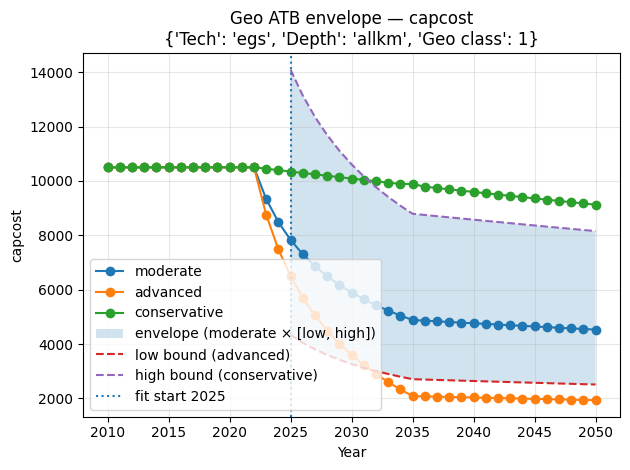

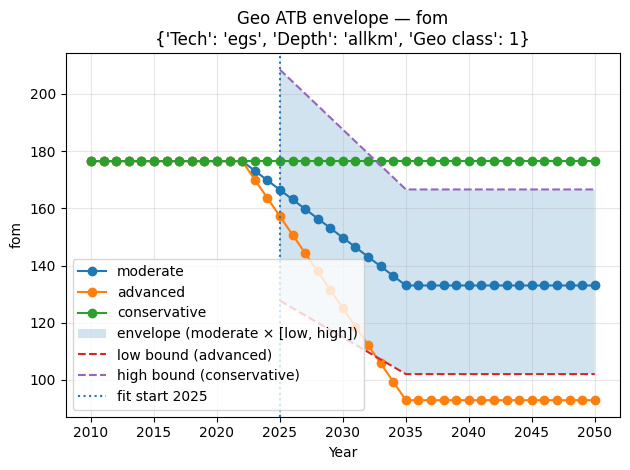

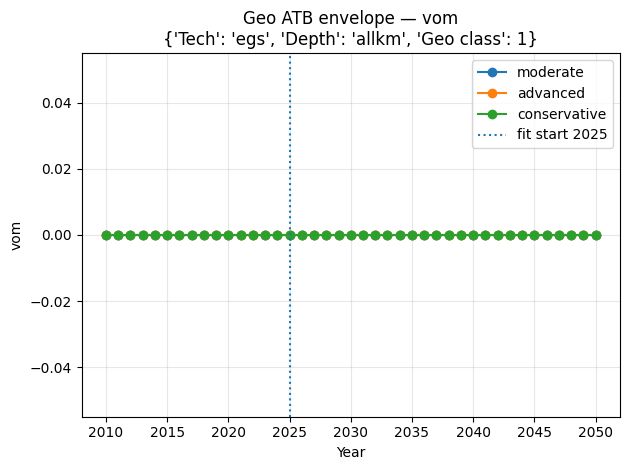

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# 0) CONFIG
# =========================
URLS = {
    "moderate": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/geo_ATB_2024_moderate.csv",
    "advanced": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/geo_ATB_2024_advanced.csv",
    "conservative": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/geo_ATB_2024_conservative.csv",
}

# Map file columns -> internal metric names (your mapping)
COLMAP = {
    "Cap cost 1000$/MW": "capcost",
    "Fixed O&M 1000$/MW-yr": "fom",
    "Var O&M $/MWh": "vom",
}

# Grouping keys in the geothermal ATB file
KEYS = ["Tech", "Depth", "Geo class"]  # plus "Year" (handled separately)

START_YEAR = 2025

# Optional filters (leave None for "all"; if only one unique value, code will auto-select)
TECH_FILTER = None
DEPTH_FILTER = None
CLASS_FILTER = None

# Output
SAVE_MULTIPLIERS_CSV = True
MULTIPLIERS_CSV = "geo_ATB_2024_envelope_multipliers.csv"
SAVE_SUMMARY_CSV = True
SUMMARY_CSV = "geo_ATB_2024_envelope_summary.csv"


# =========================
# 1) LOAD + STANDARDIZE
# =========================
def load_geo_atb(urls: dict, colmap: dict) -> pd.DataFrame:
    dfs = []
    for scen, url in urls.items():
        df = pd.read_csv(url)
        df["scenario"] = scen
        dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)

    # Basic checks
    required_cols = set(["Year", "scenario"]) | set(KEYS) | set(colmap.keys())
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(
            "Missing expected columns in geo_ATB CSV(s):\n"
            f"{missing}\n\n"
            "Tip: print(df.columns) to confirm actual names and adjust KEYS/COLMAP."
        )

    # Standardize year
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"]).copy()
    df["Year"] = df["Year"].astype(int)

    # Rename metric columns -> internal metric names
    df = df.rename(columns=colmap)

    # Keep only needed columns
    keep = ["scenario", "Year"] + KEYS + list(colmap.values())
    df = df[keep].copy()

    # Sort for sanity
    df = df.sort_values(KEYS + ["scenario", "Year"]).reset_index(drop=True)
    return df


def apply_optional_filters(df: pd.DataFrame) -> pd.DataFrame:
    global TECH_FILTER, DEPTH_FILTER, CLASS_FILTER

    # Auto-pick if only one unique and filter is None
    if TECH_FILTER is None and df["Tech"].nunique() == 1:
        TECH_FILTER = df["Tech"].iloc[0]
    if DEPTH_FILTER is None and df["Depth"].nunique() == 1:
        DEPTH_FILTER = df["Depth"].iloc[0]
    if CLASS_FILTER is None and df["Geo class"].nunique() == 1:
        CLASS_FILTER = df["Geo class"].iloc[0]

    if TECH_FILTER is not None:
        df = df[df["Tech"] == TECH_FILTER].copy()
    if DEPTH_FILTER is not None:
        df = df[df["Depth"] == DEPTH_FILTER].copy()
    if CLASS_FILTER is not None:
        df = df[df["Geo class"] == CLASS_FILTER].copy()

    return df


# =========================
# 2) LEAST-SQUARES MULTIPLIER (no intercept)
# =========================
def fit_multiplier_ls(moderate: np.ndarray, target: np.ndarray) -> float:
    mask = np.isfinite(moderate) & np.isfinite(target)
    m = moderate[mask]
    y = target[mask]
    denom = float(np.dot(m, m))
    if denom == 0.0:
        return np.nan
    return float(np.dot(m, y) / denom)


# =========================
# 3) ENVELOPE MULTIPLIERS PER GROUP
# =========================
def envelope_multipliers_for_group(
    df_group: pd.DataFrame,
    metric: str,
    start_year: int = START_YEAR
) -> dict:
    # Pivot: Year x scenario -> values
    p = df_group.pivot_table(index="Year", columns="scenario", values=metric, aggfunc="mean")

    # Require all scenarios
    need = {"moderate", "advanced", "conservative"}
    if not need.issubset(set(p.columns)):
        raise ValueError(f"Missing scenarios in pivot for metric={metric}. Found columns={list(p.columns)}")

    # Fit window
    fit = p.loc[p.index >= start_year].dropna(subset=["moderate", "advanced", "conservative"])
    if fit.empty:
        return {
            "metric": metric,
            "mA": np.nan,
            "mC": np.nan,
            "low_mult": np.nan,
            "high_mult": np.nan,
            "low_ref": None,
            "high_ref": None,
            "n_fit_years": 0,
            "fit_year_min": None,
            "fit_year_max": None,
        }

    mA = fit_multiplier_ls(fit["moderate"].to_numpy(), fit["advanced"].to_numpy())
    mC = fit_multiplier_ls(fit["moderate"].to_numpy(), fit["conservative"].to_numpy())

    # Envelope bounds
    pairs = [("advanced", mA), ("conservative", mC)]
    pairs_valid = [(name, val) for name, val in pairs if np.isfinite(val)]
    if not pairs_valid:
        low_mult = high_mult = np.nan
        low_ref = high_ref = None
    else:
        low_ref, low_mult = min(pairs_valid, key=lambda x: x[1])
        high_ref, high_mult = max(pairs_valid, key=lambda x: x[1])

    return {
        "metric": metric,
        "mA": mA,
        "mC": mC,
        "low_mult": low_mult,
        "high_mult": high_mult,
        "low_ref": low_ref,
        "high_ref": high_ref,
        "n_fit_years": int(fit.shape[0]),
        "fit_year_min": int(fit.index.min()),
        "fit_year_max": int(fit.index.max()),
    }


def compute_all_multipliers(df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    rows = []
    group_cols = KEYS

    for keys, g in df.groupby(group_cols, dropna=False):
        keys = (keys,) if not isinstance(keys, tuple) else keys
        key_dict = dict(zip(group_cols, keys))

        for metric in metrics:
            out = envelope_multipliers_for_group(g, metric, start_year=START_YEAR)
            rows.append({**key_dict, **out})

    return pd.DataFrame(rows)


# =========================
# 4) PLOT (like gas_ccs)
# =========================
def plot_envelope(df: pd.DataFrame, metric: str, selector: dict, start_year: int = START_YEAR):
    # Filter to one group
    sub = df.copy()
    for k, v in selector.items():
        sub = sub[sub[k] == v]

    if sub.empty:
        raise ValueError(f"No rows match selector={selector}")

    # Compute multipliers for that group
    mult = envelope_multipliers_for_group(sub, metric, start_year=start_year)

    p = sub.pivot_table(index="Year", columns="scenario", values=metric, aggfunc="mean").sort_index()

    # Envelope series from moderate
    years = p.index.to_numpy()
    mod = p["moderate"].to_numpy()
    env_low = mod * mult["low_mult"]
    env_high = mod * mult["high_mult"]

    # Only plot envelope for years >= start_year
    mask = years >= start_year

    plt.figure()
    # Scenario lines
    for scen in ["moderate", "advanced", "conservative"]:
        if scen in p.columns:
            plt.plot(p.index, p[scen], marker="o", label=scen)

    # Envelope shading + bounds (post start_year)
    if np.isfinite(mult["low_mult"]) and np.isfinite(mult["high_mult"]) and mask.any():
        plt.fill_between(years[mask], env_low[mask], env_high[mask], alpha=0.2, label="envelope (moderate × [low, high])")
        plt.plot(years[mask], env_low[mask], linestyle="--", label=f"low bound ({mult['low_ref']})")
        plt.plot(years[mask], env_high[mask], linestyle="--", label=f"high bound ({mult['high_ref']})")

    plt.axvline(start_year, linestyle=":", label=f"fit start {start_year}")
    plt.title(f"Geo ATB envelope — {metric}\n{selector}")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return mult


# =========================
# 5) SUMMARY TABLE (like your old 'ranges' idea)
# =========================
def summarize_ranges(mult_df: pd.DataFrame) -> pd.DataFrame:
    # Example: summarize across Geo class within each Tech/Depth/metric
    # (min/p10/median/p90/max for low/high multipliers)
    out = (
        mult_df
        .groupby(["Tech", "Depth", "metric"], dropna=False)
        .agg(
            n_groups=("low_mult", "count"),
            low_min=("low_mult", "min"),
            low_p10=("low_mult", lambda s: s.quantile(0.10)),
            low_med=("low_mult", "median"),
            low_p90=("low_mult", lambda s: s.quantile(0.90)),
            low_max=("low_mult", "max"),
            high_min=("high_mult", "min"),
            high_p10=("high_mult", lambda s: s.quantile(0.10)),
            high_med=("high_mult", "median"),
            high_p90=("high_mult", lambda s: s.quantile(0.90)),
            high_max=("high_mult", "max"),
        )
        .reset_index()
    )
    return out


# =========================
# 6) RUN
# =========================
df = load_geo_atb(URLS, COLMAP)
df = apply_optional_filters(df)

metrics = list(COLMAP.values())

# Optional: drop VOM if you know it's always zero
# df = df.drop(columns=["vom"])  # or leave it; multipliers will handle it
# metrics = [m for m in metrics if m != "vom"]

mult = compute_all_multipliers(df, metrics)

pd.set_option("display.float_format", lambda x: f"{x:0.6f}")
print("Multipliers (first 20 rows):")
print(mult.head(20))

summary = summarize_ranges(mult)
print("\nSummary ranges:")
print(summary.sort_values(["Tech", "Depth", "metric"]).head(50))

if SAVE_MULTIPLIERS_CSV:
    mult.to_csv(MULTIPLIERS_CSV, index=False)
    print(f"\nSaved multipliers to: {MULTIPLIERS_CSV}")

if SAVE_SUMMARY_CSV:
    summary.to_csv(SUMMARY_CSV, index=False)
    print(f"Saved summary to: {SUMMARY_CSV}")

# Plot example: pick the first available group (Tech/Depth/Geo class)
if not df.empty:
    first = df[KEYS].drop_duplicates().iloc[0].to_dict()
    for m in metrics:
        plot_envelope(df, m, selector=first, start_year=START_YEAR)
